In [6]:
"""
# 01 — Introducción a las Redes Neuronales Convolucionales (CNNs)

Módulo: 05 — Deep Learning para Clasificación  
Framework: TensorFlow / Keras  
Dataset: Imágenes sintéticas (generadas en este notebook)

---

## ¿Qué vamos a aprender en este notebook?

1. Por qué el Perceptrón Multicapa (MLPs) no son ideales para imágenes
2. Qué es una convolución y cómo funciona intuitivamente
3. Los bloques que forman una CNN: Conv2D, Pooling, Flatten, Dense
4. Construir y visualizar nuestra primera CNN en Keras
5. Verificar que el modelo aprende algo coherente

---
## 1. El problema con el Perceptrón Multicapa para imágenes

Cuando usamos una red neuronal densa (MLP) sobre una imagen, lo primero que hacemos
es aplanarla (flatten): convertir una imagen de 28×28 píxeles en un vector de 784 números.

Esto tiene tres problemas serios:

| Problema | Descripción |
|---|---|
| Pérdida de estructura espacial | La relación entre píxeles vecinos desaparece |
| Demasiados parámetros | Una imagen de 128×128 con 3 canales → 49,152 entradas solo para la primera capa |
| No hay invarianza | El mismo objeto en distintas posiciones produce vectores completamente distintos |

Las CNNs resuelven los tres problemas a la vez.

## 2. ¿Qué es una convolución?

Una convolución es una operación matemática que desliza un filtro (también llamado
*kernel*) sobre la imagen y calcula un producto punto en cada posición.

Imagen original      Filtro (3×3)       Mapa de activación
┌───────────────┐   ┌─────────┐         ┌───────────┐
│ 0  1  0  1  0 │   │ 1  0 -1 │         │  2  0 -2  │
│ 1  1  1  0  1 │ * │ 2  0 -2 │    =    │  4  0 -4  │
│ 0  1  0  1  0 │   │ 1  0 -1 │         │  2  0 -2  │
│ 1  0  1  1  1 │   └─────────┘         └───────────┘
│ 0  1  0  0  1 │
└───────────────┘

Lo importante: el filtro es lo que la red aprende. No le decimos qué detectar,
aprende solo a detectar bordes, texturas, formas, etc.

### Ventajas clave
- Compartición de pesos: el mismo filtro se aplica en toda la imagen → muchos menos parámetros
- Localidad: cada neurona solo ve una región pequeña de la imagen
- Composición jerárquica: capas tempranas detectan bordes, capas profundas detectan objetos

## 3. Bloques fundamentales de una CNN

### 3.1 Capa Convolucional — Conv2D
Aplica N filtros sobre la imagen. Cada filtro produce un mapa de características (feature map).

python
Conv2D(filters=32, kernel_size=(3,3), activation='relu')


### 3.2 Capa de Pooling — MaxPooling2D
Reduce el tamaño espacial tomando el valor máximo de cada región.
Aporta invarianza a pequeñas traslaciones.

Antes del pooling (4×4)    Después MaxPool 2×2 (2×2)
┌────────────────┐          ┌──────────┐
│  1   3  2   4  │          │  3   4   │
│  5   6  7   8  │   →      │  9  11   │
│  3   2  1   0  │          └──────────┘
│  9  10  11  6  │
└────────────────┘

### 3.3 Flatten + Dense
Una vez extraídas las características, se aplana el tensor y se conecta
a capas densas para la clasificación final.

### 3.4 Arquitectura típica

Input → [Conv2D → ReLU → MaxPool] × N → Flatten → Dense → Softmax → Output
"""

"\n# 01 — Introducción a las Redes Neuronales Convolucionales (CNNs)\n\nMódulo: 05 — Deep Learning para Clasificación  \nFramework: TensorFlow / Keras  \nDataset: Imágenes sintéticas (generadas en este notebook)\n\n---\n\n## ¿Qué vamos a aprender en este notebook?\n\n1. Por qué el Perceptrón Multicapa (MLPs) no son ideales para imágenes\n2. Qué es una convolución y cómo funciona intuitivamente\n3. Los bloques que forman una CNN: Conv2D, Pooling, Flatten, Dense\n4. Construir y visualizar nuestra primera CNN en Keras\n5. Verificar que el modelo aprende algo coherente\n\n---\n## 1. El problema con el Perceptrón Multicapa para imágenes\n\nCuando usamos una red neuronal densa (MLP) sobre una imagen, lo primero que hacemos\nes aplanarla (flatten): convertir una imagen de 28×28 píxeles en un vector de 784 números.\n\nEsto tiene tres problemas serios:\n\n| Problema | Descripción |\n|---|---|\n| Pérdida de estructura espacial | La relación entre píxeles vecinos desaparece |\n| Demasiados paráme

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


In [8]:
"""
## 5. Dataset sintético

Vamos a generar imágenes sintéticas de formas geométricas simples:
círculos y cuadrados. Esto nos permite:

- Controlar exactamente los datos
- Entender qué aprende la red sin ambigüedad
- No depender de ninguna descarga externa
"""

'\n## 5. Dataset sintético\n\nVamos a generar imágenes sintéticas de formas geométricas simples:\ncírculos y cuadrados. Esto nos permite:\n\n- Controlar exactamente los datos\n- Entender qué aprende la red sin ambigüedad\n- No depender de ninguna descarga externa\n'

In [9]:
def generate_circle(img_size=32):
    """Genera una imagen con un círculo blanco sobre fondo negro."""
    img = np.zeros((img_size, img_size), dtype=np.float32)
    cx = np.random.randint(8, img_size - 8)
    cy = np.random.randint(8, img_size - 8)
    r  = np.random.randint(4, 10)
    for i in range(img_size):
        for j in range(img_size):
            if (i - cy)**2 + (j - cx)**2 <= r**2:
                img[i, j] = 1.0
    return img

def generate_square(img_size=32):
    """Genera una imagen con un cuadrado blanco sobre fondo negro."""
    img = np.zeros((img_size, img_size), dtype=np.float32)
    side = np.random.randint(6, 14)
    x0   = np.random.randint(2, img_size - side - 2)
    y0   = np.random.randint(2, img_size - side - 2)
    img[y0:y0+side, x0:x0+side] = 1.0
    return img

def generate_dataset(n_samples=1000, img_size=32):
    """Genera n_samples imágenes balanceadas: mitad círculos, mitad cuadrados."""
    X, y = [], []
    for _ in range(n_samples // 2):
        X.append(generate_circle(img_size))
        y.append(0)  # 0 = círculo
    for _ in range(n_samples // 2):
        X.append(generate_square(img_size))
        y.append(1)  # 1 = cuadrado
    X = np.array(X)[..., np.newaxis]  # Agregar canal: (N, 32, 32, 1)
    y = np.array(y)
    # Shuffle
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

# Generar datos
X, y = generate_dataset(n_samples=2000)

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Clases: {np.unique(y)} — 0=círculo, 1=cuadrado")
print(f"Balance: {np.sum(y==0)} círculos | {np.sum(y==1)} cuadrados")

Shape de X: (2000, 32, 32, 1)
Shape de y: (2000,)
Clases: [0 1] — 0=círculo, 1=cuadrado
Balance: 1000 círculos | 1000 cuadrados


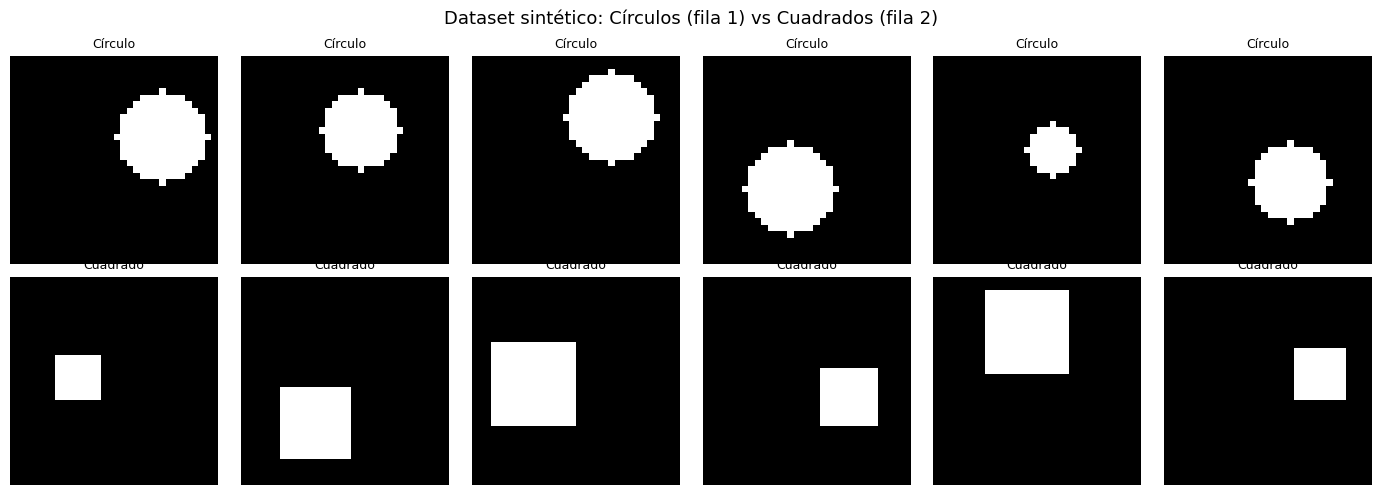

In [10]:
# Visualizar algunas muestras
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Dataset sintético: Círculos (fila 1) vs Cuadrados (fila 2)', fontsize=13)

circulos  = X[y == 0]
cuadrados = X[y == 1]

for i in range(6):
    axes[0, i].imshow(circulos[i, :, :, 0], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('Círculo', fontsize=9)

    axes[1, i].imshow(cuadrados[i, :, :, 0], cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Cuadrado', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/01_dataset_sintetico.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
"""
## 6. División train / validation / test

Dividimos el dataset en tres partes:

| Conjunto | Proporción | Para qué sirve |
|---|---|---|
| Train | 70% | Entrenar el modelo |
| Validation | 15% | Monitorear durante el entrenamiento |
| Test | 15% | Evaluación final — el modelo nunca lo vio |

El conjunto de validación nos permite detectar overfitting durante el entrenamiento sin tocar el test set.
"""

'\n## 6. División train / validation / test\n\nDividimos el dataset en tres partes:\n\n| Conjunto | Proporción | Para qué sirve |\n|---|---|---|\n| Train | 70% | Entrenar el modelo |\n| Validation | 15% | Monitorear durante el entrenamiento |\n| Test | 15% | Evaluación final — el modelo nunca lo vio |\n\nEl conjunto de validación nos permite detectar overfitting durante el entrenamiento sin tocar el test set.\n'

In [12]:
from sklearn.model_selection import train_test_split

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Val:   {X_val.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 1400 muestras
Val:   300 muestras
Test:  300 muestras


In [13]:
"""
Dragonfly 3D

## 7. Nuestra primera CNN en Keras

Vamos a construir una CNN simple con "dos bloques convolucionales"
seguidos de capas densas.
Input (32×32×1)
↓
Conv2D(16, 3×3) → ReLU
↓
MaxPooling2D(2×2)   → output: 16×16×16
↓
Conv2D(32, 3×3) → ReLU
↓
MaxPooling2D(2×2)   → output: 8×8×32
↓
Flatten             → output: 2048
↓
Dense(64) → ReLU
↓
Dense(1) → Sigmoid  → output: probabilidad de ser cuadrado

Usamos Sigmoid en la última capa porque es clasificación binaria (círculo o cuadrado). Si tuviéramos más de 2 clases usaríamos "Softmax".

"""

'\nDragonfly 3D\n\n## 7. Nuestra primera CNN en Keras\n\nVamos a construir una CNN simple con "dos bloques convolucionales"\nseguidos de capas densas.\nInput (32×32×1)\n↓\nConv2D(16, 3×3) → ReLU\n↓\nMaxPooling2D(2×2)   → output: 16×16×16\n↓\nConv2D(32, 3×3) → ReLU\n↓\nMaxPooling2D(2×2)   → output: 8×8×32\n↓\nFlatten             → output: 2048\n↓\nDense(64) → ReLU\n↓\nDense(1) → Sigmoid  → output: probabilidad de ser cuadrado\n\nUsamos Sigmoid en la última capa porque es clasificación binaria (círculo o cuadrado). Si tuviéramos más de 2 clases usaríamos "Softmax".\n\n'

In [20]:
def build_cnn(input_shape=(32, 32, 1)):
    model = keras.Sequential([
        # --- Bloque 1 ---
        layers.Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # --- Bloque 2 ---
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # --- Clasificador ---
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # Clasificación binaria
    ])
    return model

model = build_cnn()
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 32, 32, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 16, 16, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 136,001 (531.25 KB)

 Trainable params: 136,001 (531.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
"""
## 8. Interpretando el "model.summary()"

| Columna | Qué significa |
|---|---|
| Layer | Nombre y tipo de cada capa |
| Output Shape | Dimensiones del tensor que sale de esa capa |
| Param # | Parámetros entrenables de esa capa |

### ¿Cómo se calculan los parámetros de una Conv2D?

Conv2D(16, 3×3) sobre input de 1 canal:
parámetros = (3 × 3 × 1 + 1) × 16 = 160
kernel    bias   filtros
### ¿Cómo se calculan los parámetros de una Dense?
Dense(64) con 2048 entradas:
parámetros = (2048 + 1) × 64 = 131,136
inputs  bias   neuronas
Notá que las capas Conv2D tienen muchos menos parámetros que las capas Dense — esa es una de las grandes ventajas de las CNNs sobre los MLPs.
"""

'\n## 8. Interpretando el "model.summary()"\n\n| Columna | Qué significa |\n|---|---|\n| Layer | Nombre y tipo de cada capa |\n| Output Shape | Dimensiones del tensor que sale de esa capa |\n| Param # | Parámetros entrenables de esa capa |\n\n### ¿Cómo se calculan los parámetros de una Conv2D?\n\nConv2D(16, 3×3) sobre input de 1 canal:\nparámetros = (3 × 3 × 1 + 1) × 16 = 160\nkernel    bias   filtros\n### ¿Cómo se calculan los parámetros de una Dense?\nDense(64) con 2048 entradas:\nparámetros = (2048 + 1) × 64 = 131,136\ninputs  bias   neuronas\nNotá que las capas Conv2D tienen muchos menos parámetros que las capas Dense — esa es una de las grandes ventajas de las CNNs sobre los MLPs.\n'

In [22]:
"""
## 9. Compilar y entrenar

Antes de entrenar hay que compilar el modelo, lo que significa definir tres cosas:

| Parámetro | Qué es | Nuestra elección |
|---|---|---|
| optimizer | Algoritmo que actualiza los pesos | "adam" |
| loss | Función que mide el error | "binary_crossentropy" |
| metrics | Métrica para monitorear | "accuracy" |

### ¿Por qué "binary_crossentropy"?
Porque tenemos dos clases (círculo y cuadrado) y la salida es una
probabilidad entre 0 y 1. Si tuviéramos más clases usaríamos "categorical_crossentropy".

### ¿Por qué "adam"?
Es el optimizador más usado como punto de partida — adapta la tasa de
aprendizaje automáticamente durante el entrenamiento.
En el notebook 08 vamos a comparar distintos optimizadores en detalle.
"""


'\n## 9. Compilar y entrenar\n\nAntes de entrenar hay que compilar el modelo, lo que significa definir tres cosas:\n\n| Parámetro | Qué es | Nuestra elección |\n|---|---|---|\n| optimizer | Algoritmo que actualiza los pesos | "adam" |\n| loss | Función que mide el error | "binary_crossentropy" |\n| metrics | Métrica para monitorear | "accuracy" |\n\n### ¿Por qué "binary_crossentropy"?\nPorque tenemos dos clases (círculo y cuadrado) y la salida es una\nprobabilidad entre 0 y 1. Si tuviéramos más clases usaríamos "categorical_crossentropy".\n\n### ¿Por qué "adam"?\nEs el optimizador más usado como punto de partida — adapta la tasa de\naprendizaje automáticamente durante el entrenamiento.\nEn el notebook 08 vamos a comparar distintos optimizadores en detalle.\n'

In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Clasificación binaria
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7193 - loss: 0.5498 - val_accuracy: 0.8867 - val_loss: 0.3224
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9879 - loss: 0.0931 - val_accuracy: 1.0000 - val_loss: 0.0129
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 7.8344e-04 - val_accuracy: 1.0000 - val_loss: 8.0666e-04
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 5.6178e-04 - val_accuracy: 1.0000 - val_loss: 5.9799e-04
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 4.2516e-04 - val_

In [24]:
"""
## 10. Visualizar el entrenamiento

Las curvas de loss y accuracy a lo largo de las epochs nos permiten entender cómo aprendió el modelo:

- Si train y val se mueven juntas → el modelo está aprendiendo bien
- Si train baja pero val sube → overfitting (el modelo memoriza en vez de generalizar)
- Si ambas se estancan en valores altos → underfitting (el modelo es muy simple)

Estos conceptos los vamos a profundizar en el notebook 07.
"""

'\n## 10. Visualizar el entrenamiento\n\nLas curvas de loss y accuracy a lo largo de las epochs nos permiten entender cómo aprendió el modelo:\n\n- Si train y val se mueven juntas → el modelo está aprendiendo bien\n- Si train baja pero val sube → overfitting (el modelo memoriza en vez de generalizar)\n- Si ambas se estancan en valores altos → underfitting (el modelo es muy simple)\n\nEstos conceptos los vamos a profundizar en el notebook 07.\n'

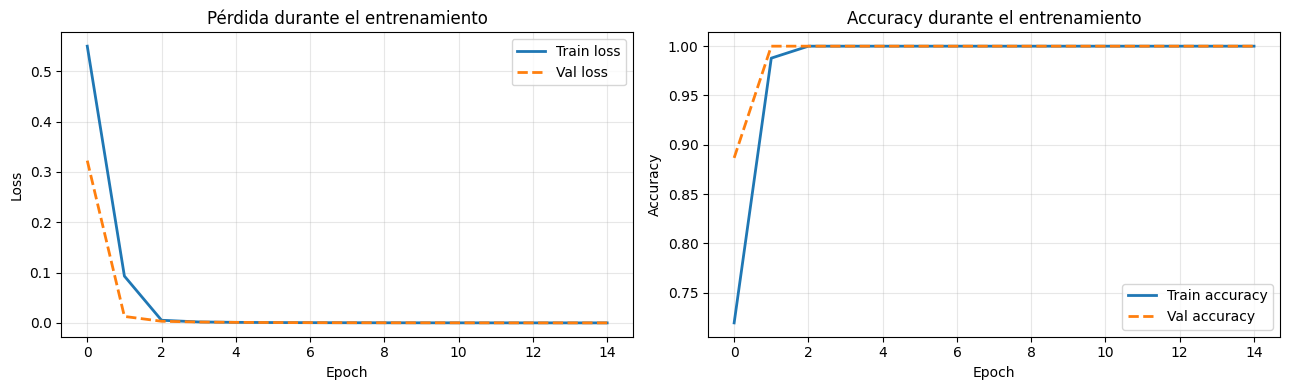

In [25]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Loss
    axes[0].plot(history.history['loss'],     label='Train loss',  linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val loss',    linewidth=2, linestyle='--')
    axes[0].set_title('Pérdida durante el entrenamiento')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train accuracy',  linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val accuracy',    linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy durante el entrenamiento')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('../figures/01_training_history.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_history(history)

In [26]:
"""
## 11. Evaluación en el conjunto de test

Hasta ahora usamos el conjunto de validación para monitorear el entrenamiento.
Ahora evaluamos sobre el "test set" — datos que el modelo nunca vio en ningún
momento del proceso.

Esta es la métrica que realmente importa. Un modelo puede tener val_accuracy perfecto pero fallar en producción si hubo algún tipo de fuga de información entre train y validación.
"""

'\n## 11. Evaluación en el conjunto de test\n\nHasta ahora usamos el conjunto de validación para monitorear el entrenamiento.\nAhora evaluamos sobre el "test set" — datos que el modelo nunca vio en ningún\nmomento del proceso.\n\nEsta es la métrica que realmente importa. Un modelo puede tener val_accuracy perfecto pero fallar en producción si hubo algún tipo de fuga de información entre train y validación.\n'

In [27]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

Test Loss:     0.0001
Test Accuracy: 1.0000 (100.0%)


In [28]:
"""
## 12. Visualizar predicciones

Ver los resultados numéricos está bien, pero visualizar las predicciones
directamente sobre las imágenes nos da una intuición mucho más clara de
cómo está funcionando el modelo.

- Verde → predicción correcta
- Rojo → predicción incorrecta
"""

'\n## 12. Visualizar predicciones\n\nVer los resultados numéricos está bien, pero visualizar las predicciones\ndirectamente sobre las imágenes nos da una intuición mucho más clara de\ncómo está funcionando el modelo.\n\n- Verde → predicción correcta\n- Rojo → predicción incorrecta\n'

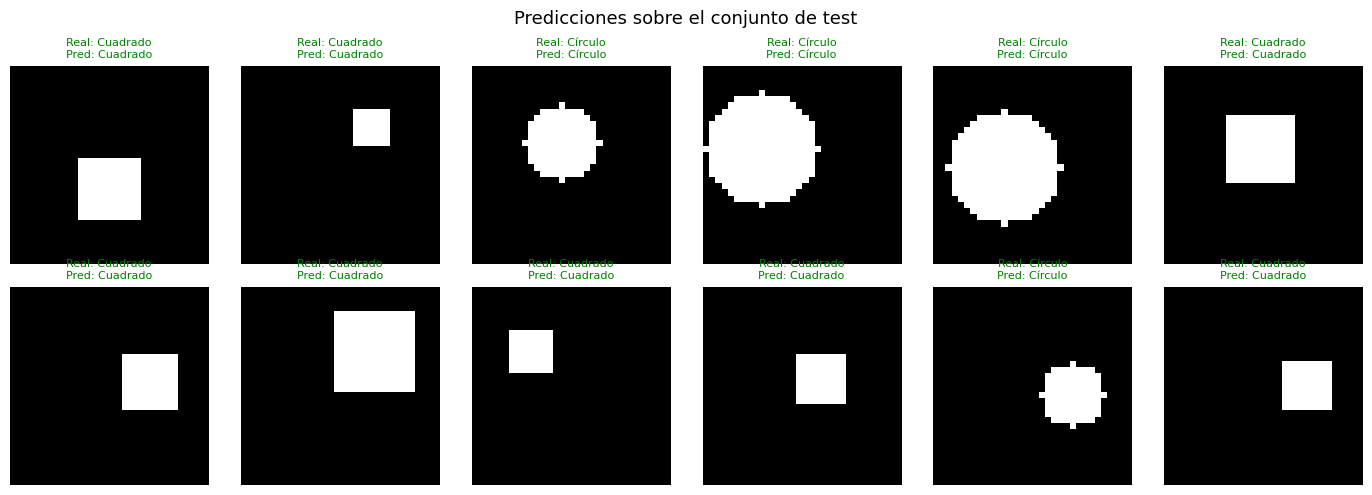

Verde = correcto | Rojo = error


In [29]:
class_names = ['Círculo', 'Cuadrado']
preds = model.predict(X_test[:12], verbose=0)
pred_classes = (preds > 0.5).astype(int).flatten()

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Predicciones sobre el conjunto de test', fontsize=13)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_test[i, :, :, 0], cmap='gray')
    true_label = class_names[y_test[i]]
    pred_label = class_names[pred_classes[i]]
    color = 'green' if pred_classes[i] == y_test[i] else 'red'
    ax.set_title(f'Real: {true_label}\nPred: {pred_label}', fontsize=8, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../figures/01_predicciones_test.png', dpi=120, bbox_inches='tight')
plt.show()
print("Verde = correcto | Rojo = error")

In [30]:
model.save('../models/01_first_cnn.keras')
print("Modelo guardado en ../models/01_first_cnn.keras")

Modelo guardado en ../models/01_first_cnn.keras


In [31]:
"""
## Resumen del notebook

| Concepto | Lo que aprendimos |
|---|---|
| Motivación | Los MLPs pierden estructura espacial al aplanar imágenes |
| Convolución | Un filtro que se desliza por la imagen y detecta patrones locales |
| MaxPooling | Reduce el tamaño espacial y aporta invarianza |
| Arquitectura | Conv → Pool → Conv → Pool → Flatten → Dense → Output |
| Entrenamiento | "model.compile()" + "model.fit()" con curvas de loss/accuracy |
| Evaluación | "model.evaluate()" sobre el conjunto de test |
---
## ¿Qué sigue?
En el siguiente notebook vamos a aplicar una CNN al dataset MNIST (dígitos
escritos a mano), un benchmark clásico para clasificación de imágenes,
y vamos a analizar métricas más detalladas como la matriz de confusión.
"""

'\n## Resumen del notebook\n\n| Concepto | Lo que aprendimos |\n|---|---|\n| Motivación | Los MLPs pierden estructura espacial al aplanar imágenes |\n| Convolución | Un filtro que se desliza por la imagen y detecta patrones locales |\n| MaxPooling | Reduce el tamaño espacial y aporta invarianza |\n| Arquitectura | Conv → Pool → Conv → Pool → Flatten → Dense → Output |\n| Entrenamiento | "model.compile()" + "model.fit()" con curvas de loss/accuracy |\n| Evaluación | "model.evaluate()" sobre el conjunto de test |\n---\n## ¿Qué sigue?\nEn el siguiente notebook vamos a aplicar una CNN al dataset MNIST (dígitos\nescritos a mano), un benchmark clásico para clasificación de imágenes,\ny vamos a analizar métricas más detalladas como la matriz de confusión.\n'